In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
uploaded=files.upload()

Saving train.csv.zip to train.csv.zip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

In [5]:
print("Loading data...")
df = pd.read_csv("train.csv.zip")   # change path if needed
print(f"Shape: {df.shape}")
print(f"Activities: {df['Activity'].unique()}")
print(f"Null values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Loading data...
Shape: (7352, 563)
Activities: ['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Null values: 0
Duplicates: 0


In [9]:
df = pd.read_csv("train.csv.zip")
print(f"Shape: {df.shape}")

Shape: (7352, 563)


In [10]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,0.274488,0.070261,-1.000000,0.262975,0.277193,0.288461,1.000000
tBodyAcc-mean()-Y,7352.0,-0.017695,0.040811,-1.000000,-0.024863,-0.017219,-0.010783,1.000000
tBodyAcc-mean()-Z,7352.0,-0.109141,0.056635,-1.000000,-0.120993,-0.108676,-0.097794,1.000000
tBodyAcc-std()-X,7352.0,-0.605438,0.448734,-1.000000,-0.992754,-0.946196,-0.242813,1.000000
tBodyAcc-std()-Y,7352.0,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238
...,...,...,...,...,...,...,...,...
"angle(tBodyGyroJerkMean,gravityMean)",7352.0,-0.005981,0.477975,-1.000000,-0.376341,-0.000368,0.359368,0.996078
"angle(X,gravityMean)",7352.0,-0.489547,0.511807,-1.000000,-0.812065,-0.709417,-0.509079,1.000000
"angle(Y,gravityMean)",7352.0,0.058593,0.297480,-1.000000,-0.017885,0.182071,0.248353,0.478157
"angle(Z,gravityMean)",7352.0,-0.056515,0.279122,-1.000000,-0.143414,0.003181,0.107659,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [13]:
print('Null values:  ', df.isnull().sum().sum())
print('Duplicates:   ', df.duplicated().sum())

Null values:   0
Duplicates:    0


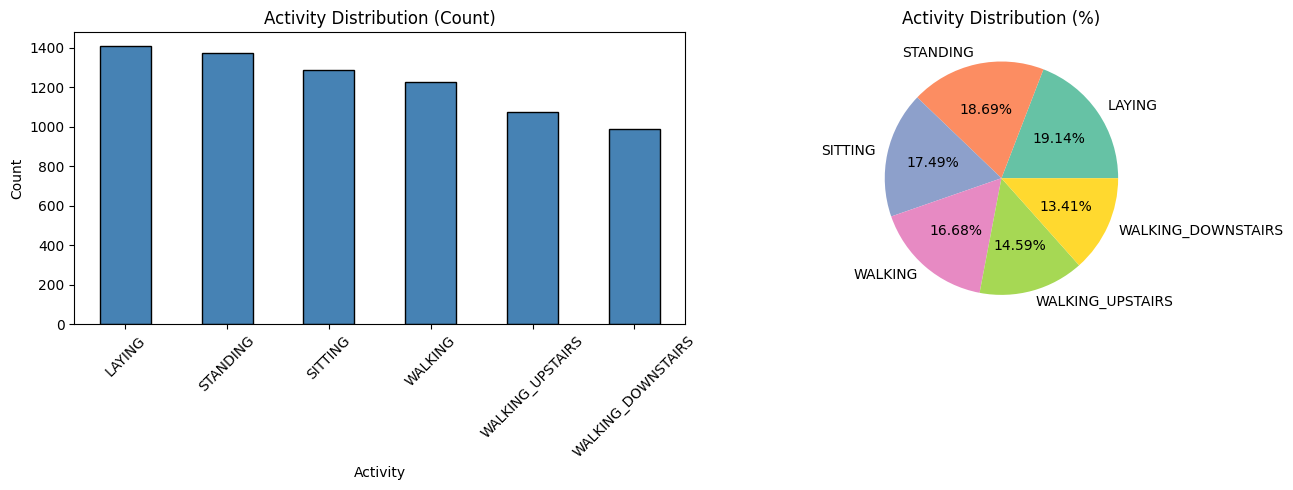

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Activity'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Activity Distribution (Count)')
axes[0].set_xlabel('Activity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

round(df['Activity'].value_counts() / df.shape[0] * 100, 2).plot.pie(
    ax=axes[1], autopct='%1.2f%%', colors=sns.color_palette('Set2', 6)
)
axes[1].set_title('Activity Distribution (%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

================== STANDING - acc ==================


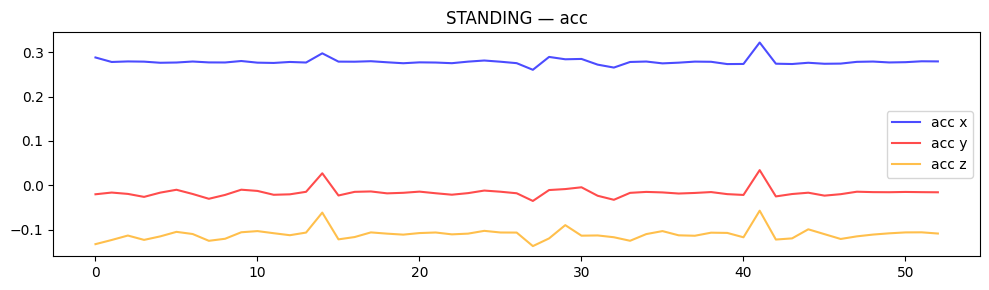

================== STANDING - gyro ==================


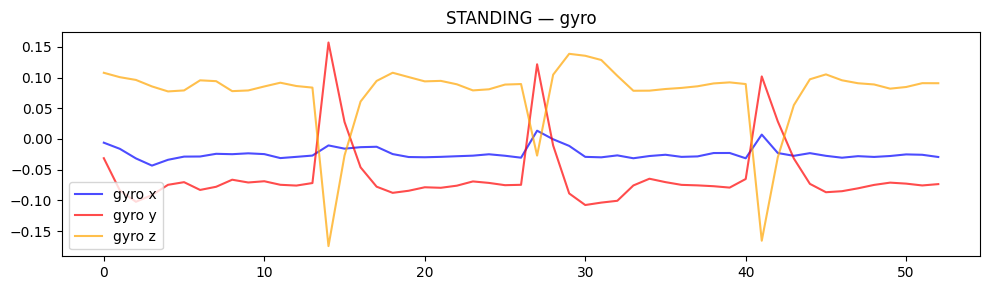

================== SITTING - acc ==================


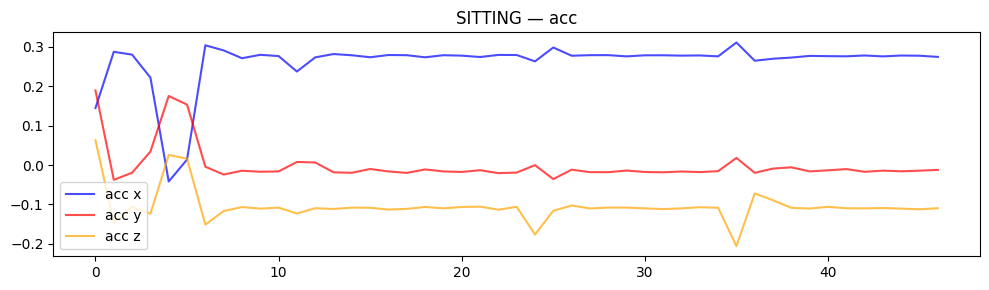

================== SITTING - gyro ==================


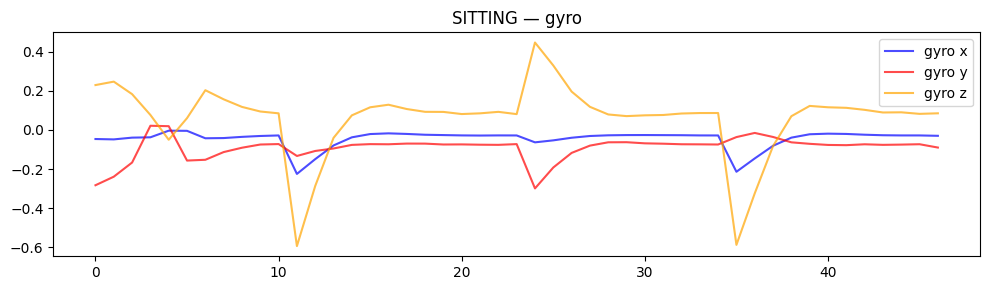

================== LAYING - acc ==================


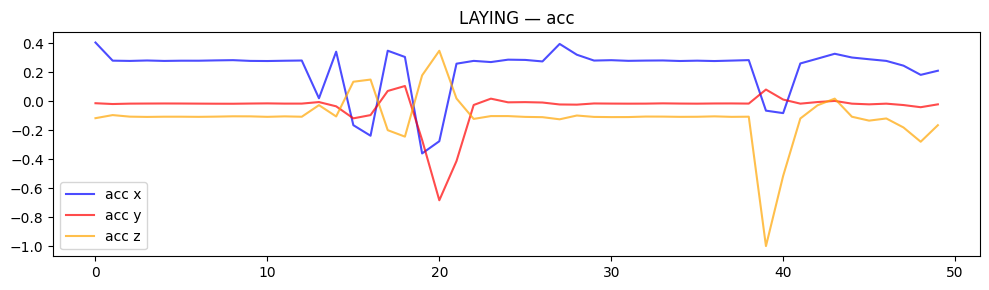

================== LAYING - gyro ==================


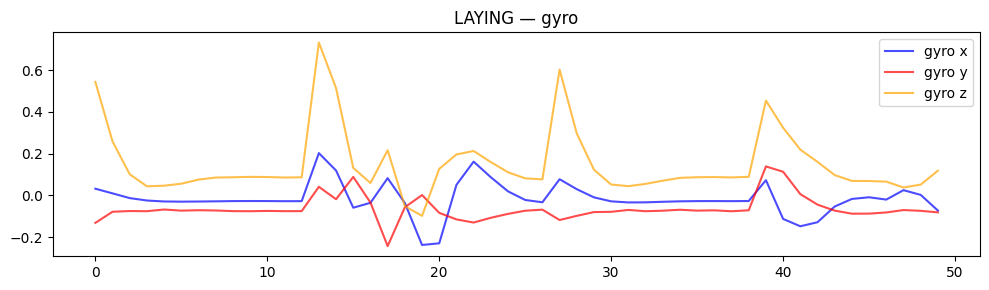

================== WALKING - acc ==================


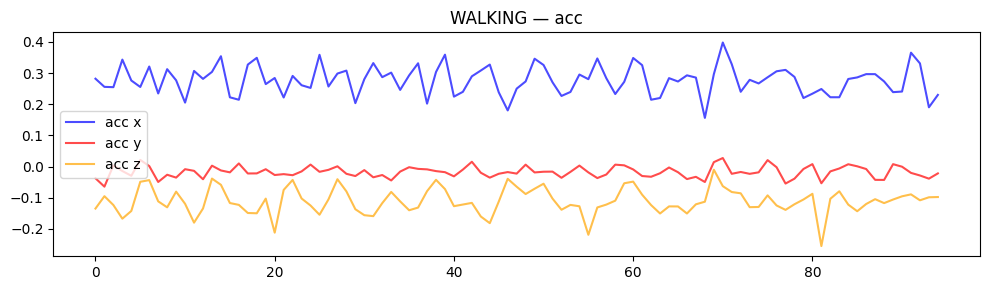

================== WALKING - gyro ==================


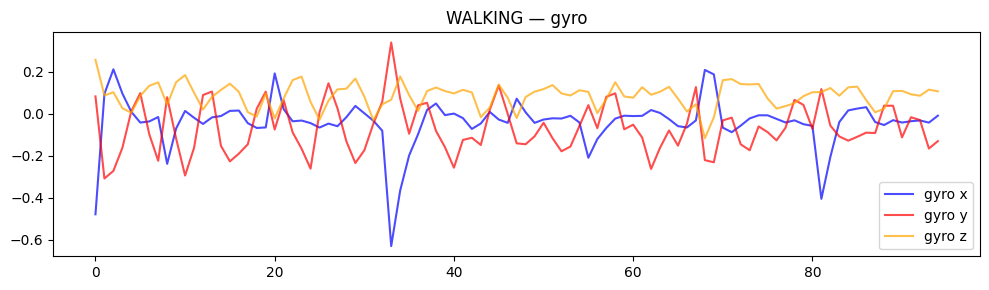

================== WALKING_DOWNSTAIRS - acc ==================


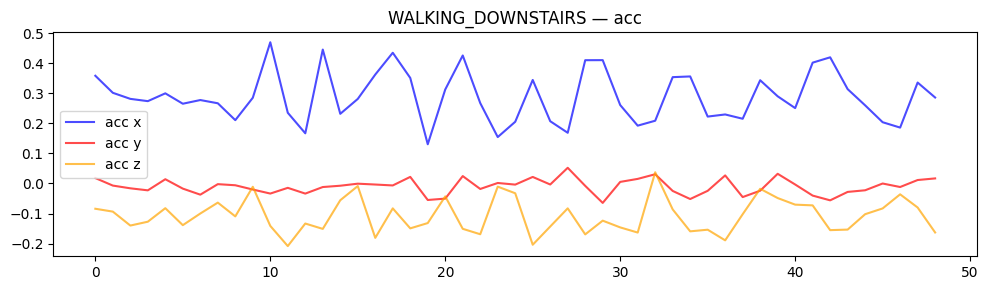

================== WALKING_DOWNSTAIRS - gyro ==================


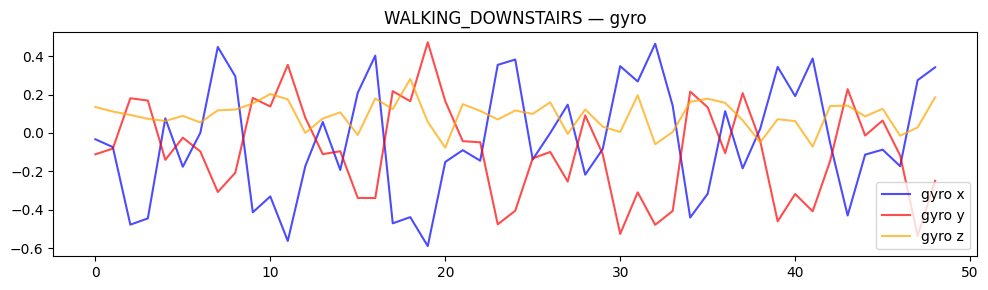

================== WALKING_UPSTAIRS - acc ==================


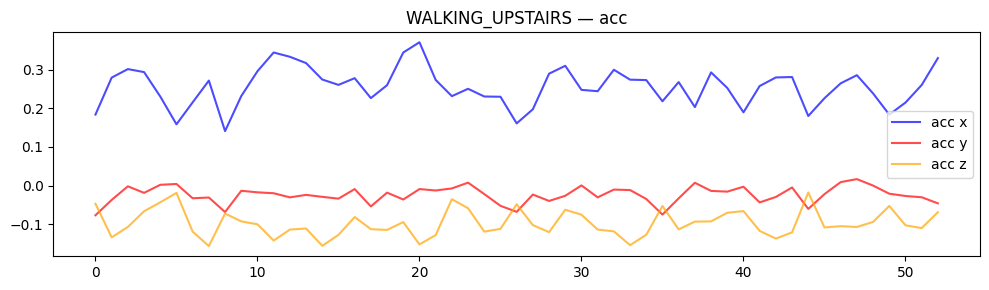

================== WALKING_UPSTAIRS - gyro ==================


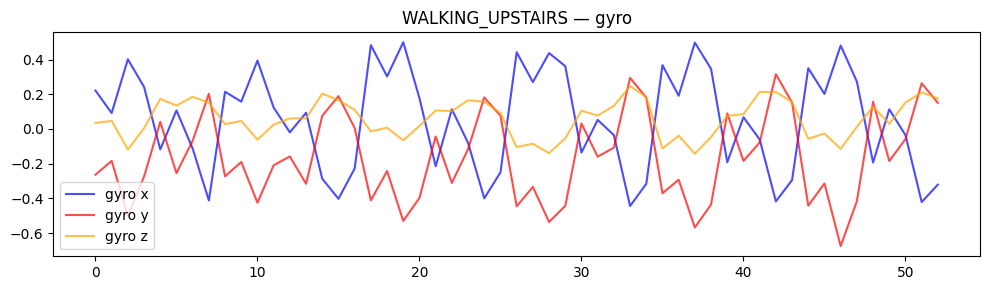

In [15]:
subject1 = df[df['subject'] == 1]

readings = {
    'acc':  ['tBodyAcc-mean()-X',  'tBodyAcc-mean()-Y',  'tBodyAcc-mean()-Z'],
    'gyro': ['tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z']
}

for activity in subject1['Activity'].unique():
    data = subject1[subject1['Activity'] == activity].reset_index(drop=True)
    for rtype, ax_cols in readings.items():
        print(f"================== {activity} - {rtype} ==================")
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(data[ax_cols[0]], label=f"{rtype} x", color='blue',   alpha=0.7)
        ax.plot(data[ax_cols[1]], label=f"{rtype} y", color='red',    alpha=0.7)
        ax.plot(data[ax_cols[2]], label=f"{rtype} z", color='orange', alpha=0.7)
        ax.set_title(f"{activity} — {rtype}")
        ax.legend()
        plt.tight_layout()
        plt.show()

================== STANDING - acc ==================


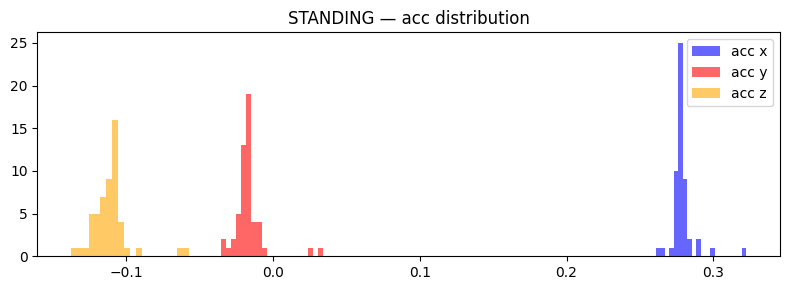

================== STANDING - gyro ==================


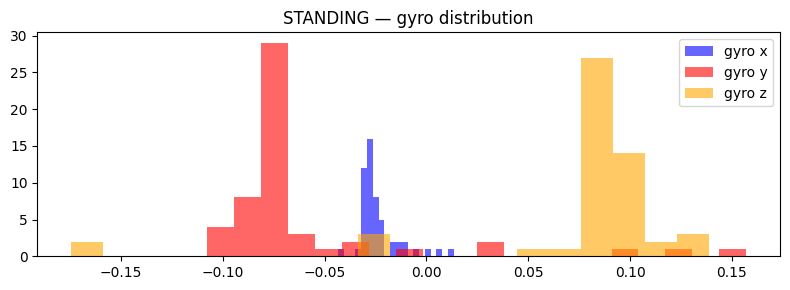

================== SITTING - acc ==================


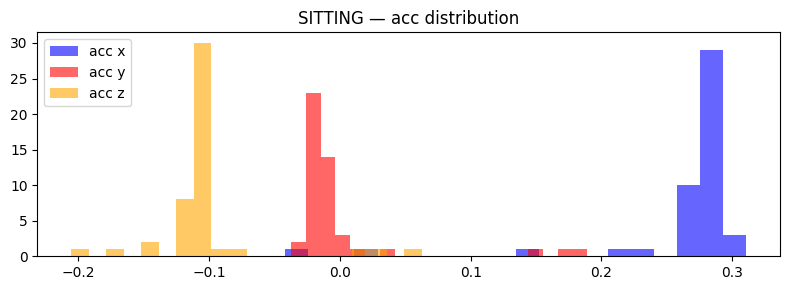

================== SITTING - gyro ==================


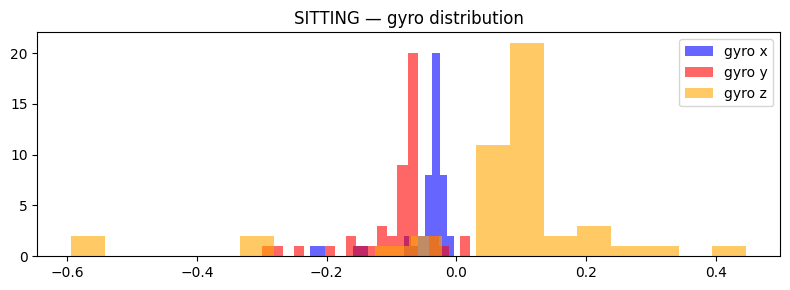

================== LAYING - acc ==================


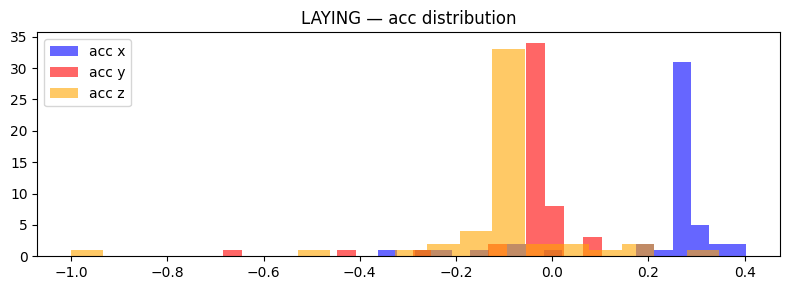

================== LAYING - gyro ==================


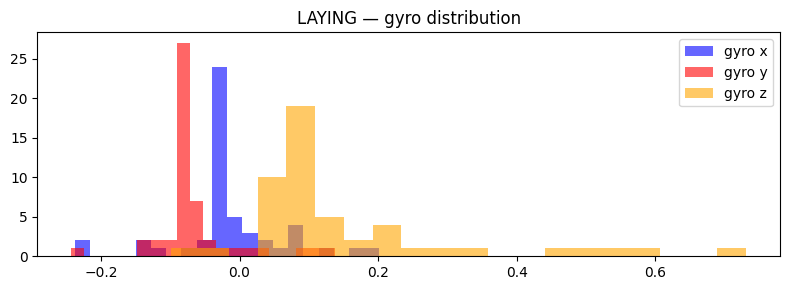

================== WALKING - acc ==================


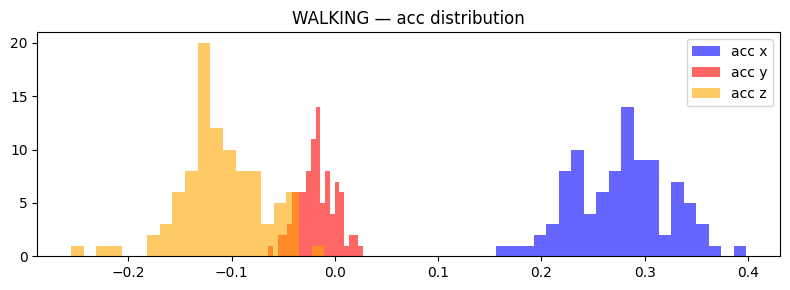

================== WALKING - gyro ==================


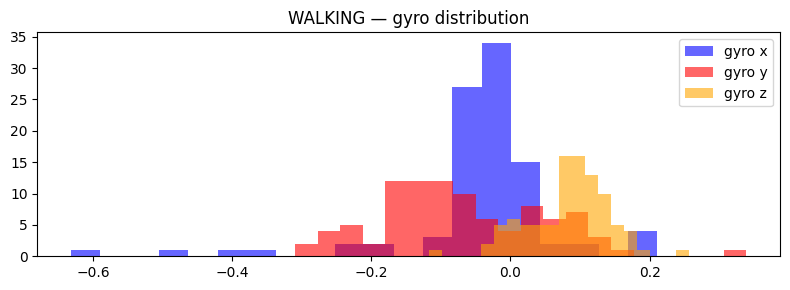

================== WALKING_DOWNSTAIRS - acc ==================


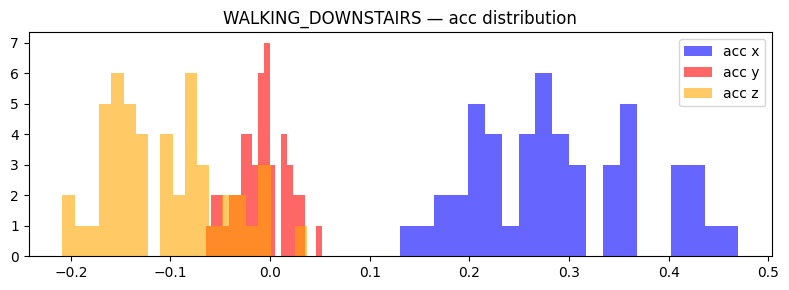

================== WALKING_DOWNSTAIRS - gyro ==================


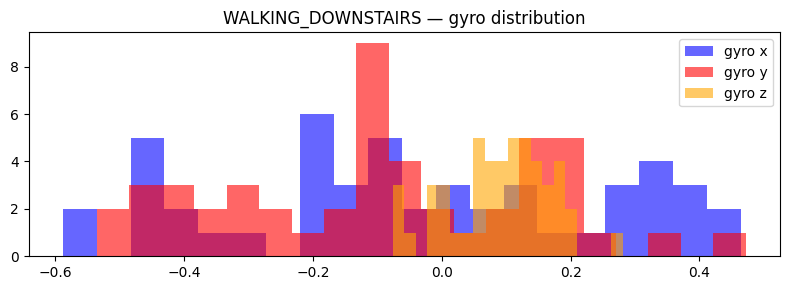

================== WALKING_UPSTAIRS - acc ==================


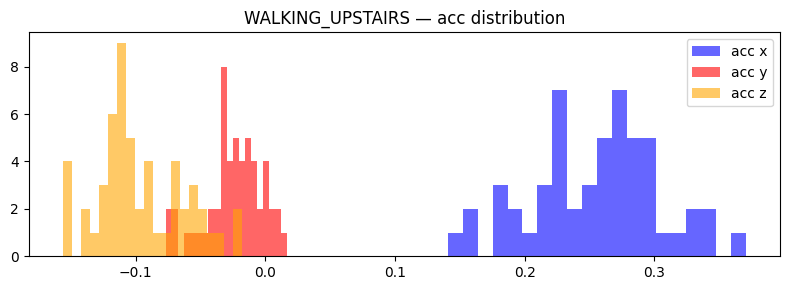

================== WALKING_UPSTAIRS - gyro ==================


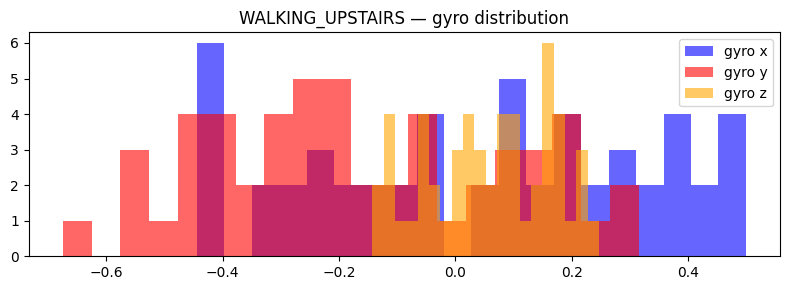

In [16]:
for activity in subject1['Activity'].unique():
    data = subject1[subject1['Activity'] == activity].reset_index(drop=True)
    for rtype, ax_cols in readings.items():
        print(f"================== {activity} - {rtype} ==================")
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.hist(data[ax_cols[0]], label=f"{rtype} x", color='blue',   alpha=0.6, bins=20)
        ax.hist(data[ax_cols[1]], label=f"{rtype} y", color='red',    alpha=0.6, bins=20)
        ax.hist(data[ax_cols[2]], label=f"{rtype} z", color='orange', alpha=0.6, bins=20)
        ax.set_title(f"{activity} — {rtype} distribution")
        ax.legend()
        plt.tight_layout()
        plt.show()

In [17]:
# Encode target BEFORE splitting
le = LabelEncoder()
df['Activity_enc'] = le.fit_transform(df['Activity'])

print("Activity encoding:")
for i, name in enumerate(le.classes_):
    print(f"  {i} -> {name}")

# activity_labels aligned to LabelEncoder order — used in confusion matrix
activity_labels = dict(enumerate(le.classes_))

Activity encoding:
  0 -> LAYING
  1 -> SITTING
  2 -> STANDING
  3 -> WALKING
  4 -> WALKING_DOWNSTAIRS
  5 -> WALKING_UPSTAIRS


In [18]:
X = df.drop(['Activity', 'Activity_enc', 'subject'], axis=1).values
y = df['Activity_enc'].values

# Stratified split so all 6 classes are proportionally represented
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler ONLY on train — prevents data leakage into test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")

Train: (5881, 561)  |  Test: (1471, 561)


In [19]:
def resultsSummerizer(y_true, y_pred, cm_en=True):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec  = recall_score(y_true, y_pred, average='macro')
    f1   = f1_score(y_true, y_pred, average='macro')

    if cm_en:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=activity_labels.values(),
                    yticklabels=activity_labels.values())
        plt.title("Confusion Matrix")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.show()

    print(f'Accuracy:  {acc:.4%}')
    print(f'Precision: {prec:.4%}')
    print(f'F1 Score:  {f1:.4%}')
    print(f'Recall:    {rec:.4%}')

In [20]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Test  accuracy:", lr.score(X_test_scaled,  y_test))

Train accuracy: 0.9964291787111036
Test  accuracy: 0.9857239972807614


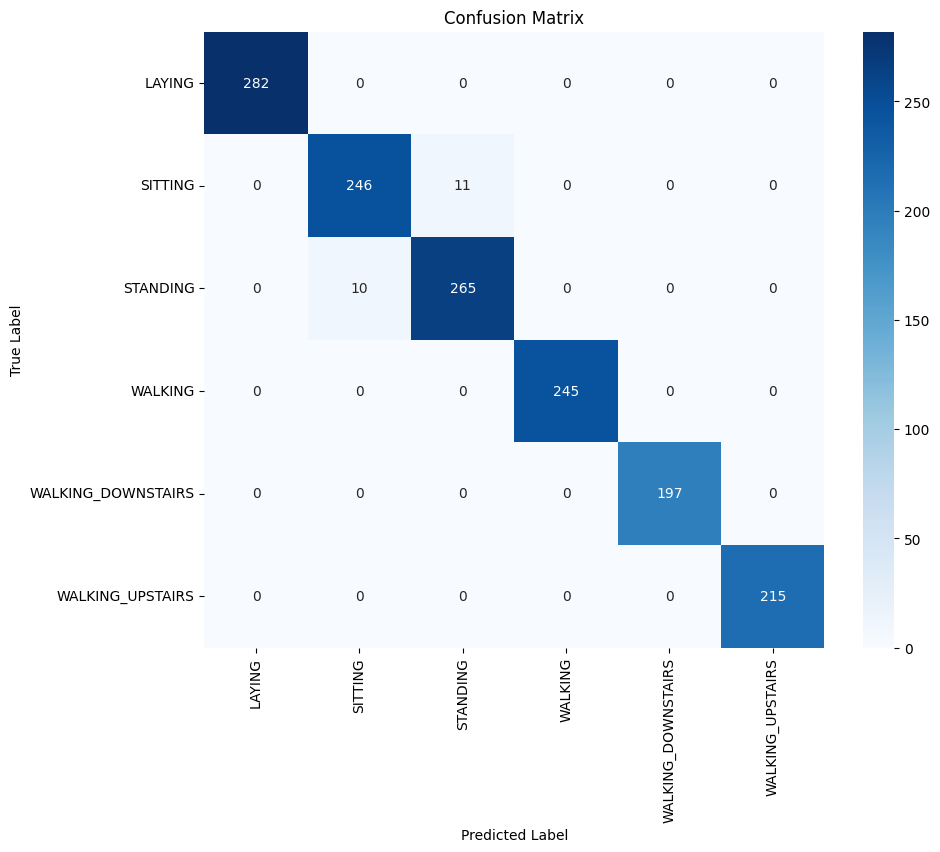

Accuracy:  98.5724%
Precision: 98.6847%
F1 Score:  98.6825%
Recall:    98.6806%


In [21]:
y_pred_lr = lr.predict(X_test_scaled)
resultsSummerizer(y_test, y_pred_lr)

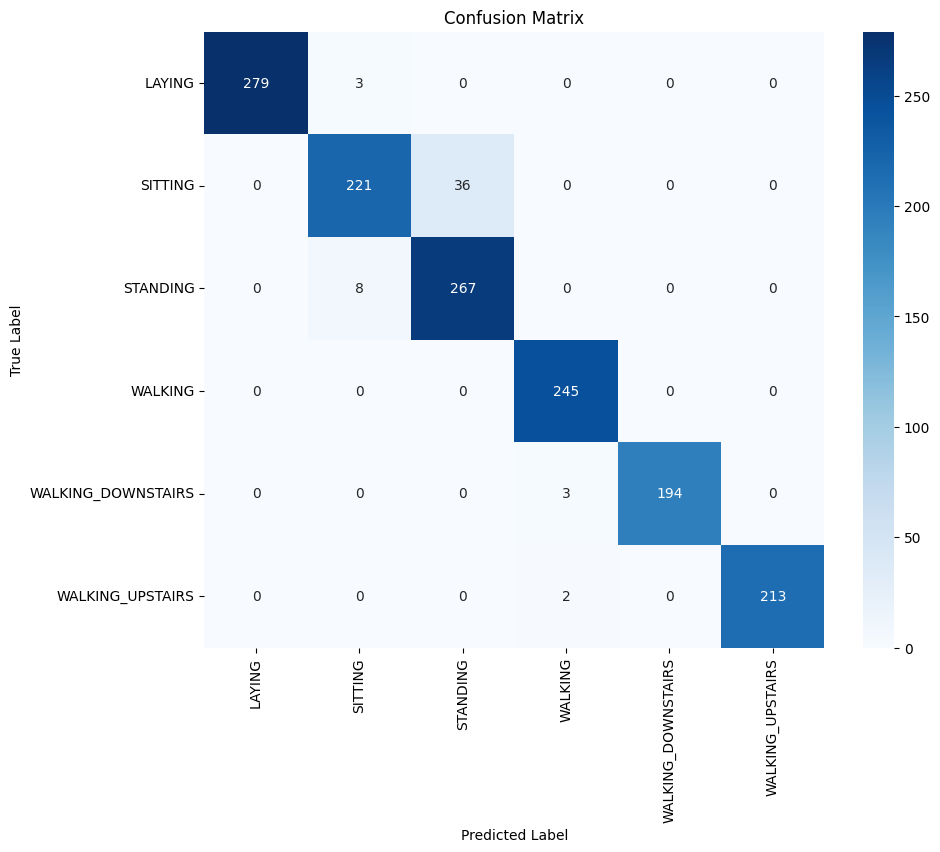

Accuracy:  96.4650%
Precision: 96.8962%
F1 Score:  96.6661%
Recall:    96.5944%


In [22]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
resultsSummerizer(y_test, y_pred_knn)

In [23]:
for n in range(1, 11):
    knn_n = KNeighborsClassifier(n_neighbors=n)
    knn_n.fit(X_train_scaled, y_train)
    y_pred_n = knn_n.predict(X_test_scaled)
    print(f"\n==== k={n} ====")
    resultsSummerizer(y_test, y_pred_n, cm_en=False)


==== k=1 ====
Accuracy:  96.3290%
Precision: 96.6093%
F1 Score:  96.5626%
Recall:    96.5311%

==== k=2 ====
Accuracy:  95.5812%
Precision: 95.9999%
F1 Score:  95.7946%
Recall:    95.7938%

==== k=3 ====
Accuracy:  96.4650%
Precision: 96.7507%
F1 Score:  96.6383%
Recall:    96.5884%

==== k=4 ====
Accuracy:  96.3290%
Precision: 96.5713%
F1 Score:  96.5085%
Recall:    96.4648%

==== k=5 ====
Accuracy:  96.4650%
Precision: 96.8962%
F1 Score:  96.6661%
Recall:    96.5944%

==== k=6 ====
Accuracy:  96.6010%
Precision: 96.8569%
F1 Score:  96.7806%
Recall:    96.7226%

==== k=7 ====
Accuracy:  95.6492%
Precision: 96.1341%
F1 Score:  95.8803%
Recall:    95.8078%

==== k=8 ====
Accuracy:  96.1931%
Precision: 96.5097%
F1 Score:  96.3691%
Recall:    96.2954%

==== k=9 ====
Accuracy:  95.7852%
Precision: 96.3343%
F1 Score:  96.0087%
Recall:    95.9304%

==== k=10 ====
Accuracy:  96.3970%
Precision: 96.7663%
F1 Score:  96.5881%
Recall:    96.5152%


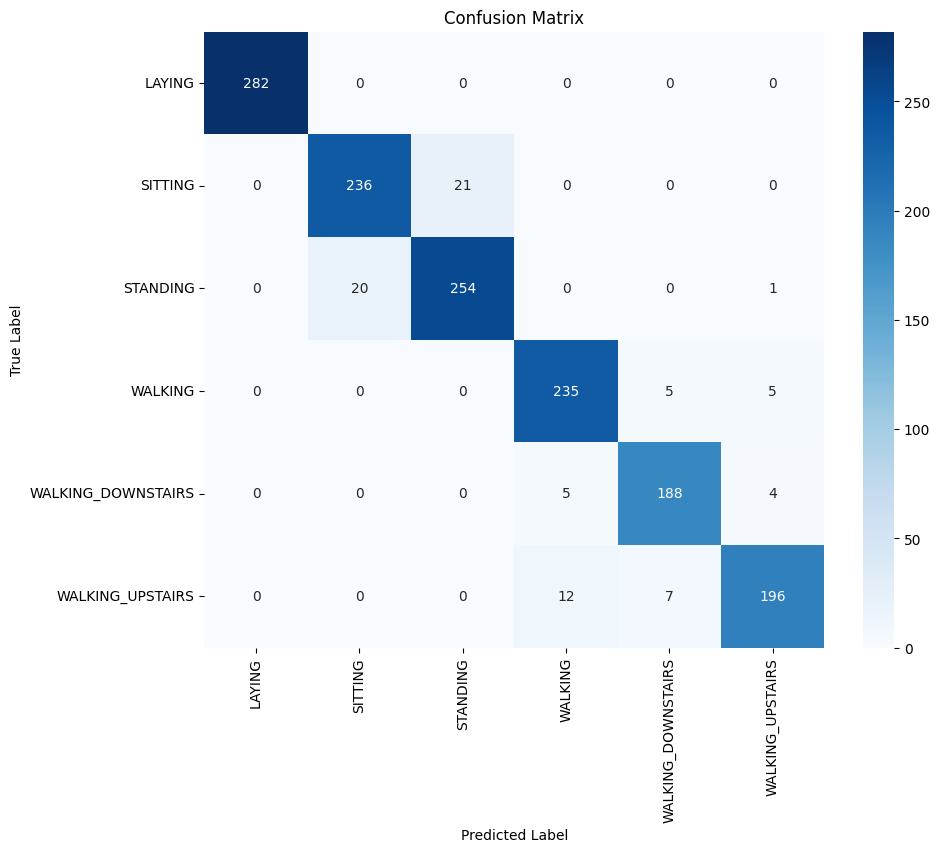

Accuracy:  94.5615%
Precision: 94.4918%
F1 Score:  94.4601%
Recall:    94.4508%


In [24]:
dt = DecisionTreeClassifier(max_depth=14, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
resultsSummerizer(y_test, y_pred_dt)

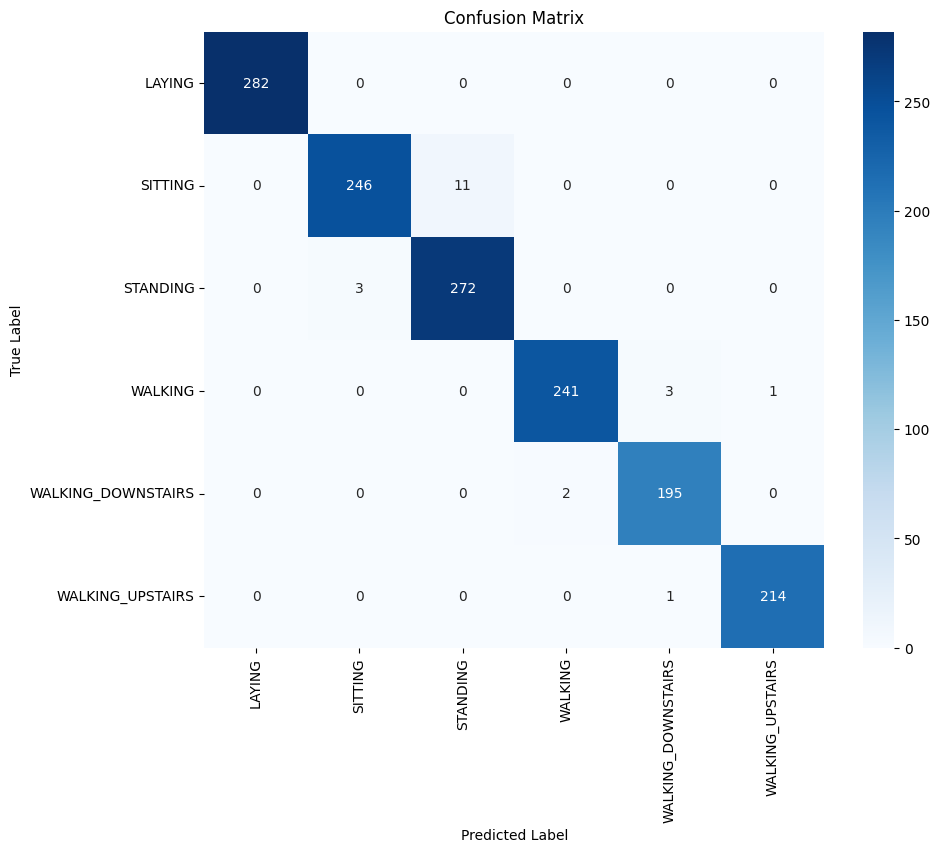

Accuracy:  98.5724%
Precision: 98.6017%
F1 Score:  98.5857%
Recall:    98.5860%


In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
resultsSummerizer(y_test, y_pred_rf)

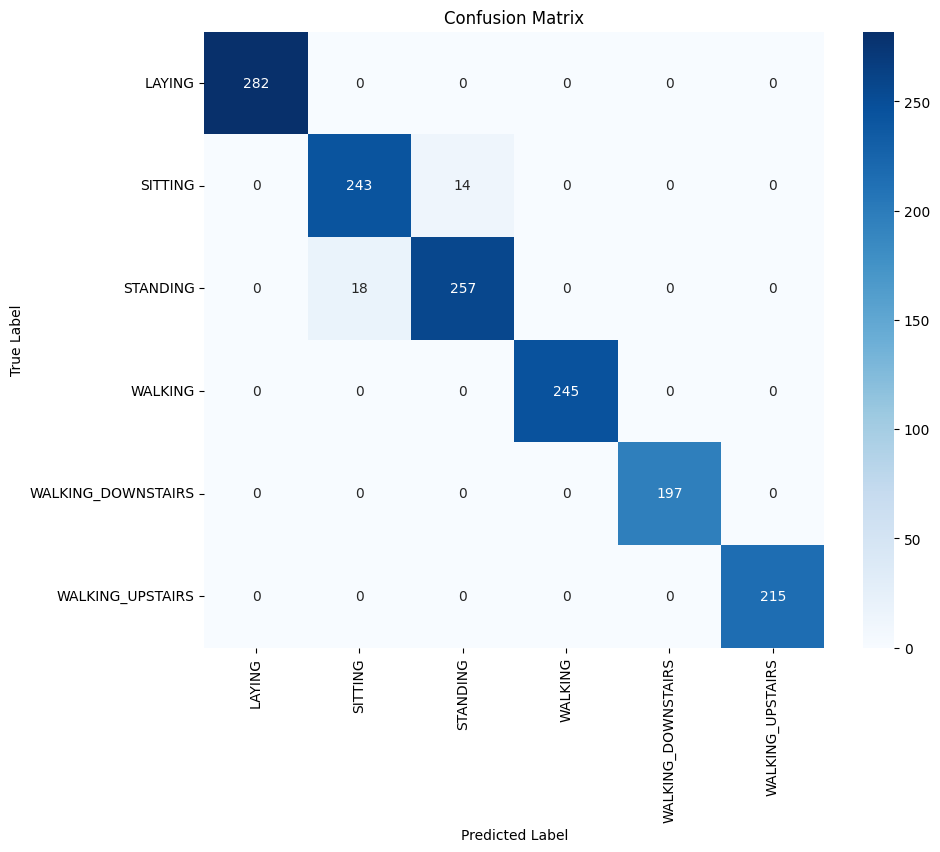

Accuracy:  97.8246%
Precision: 97.9896%
F1 Score:  97.9936%
Recall:    98.0012%


In [26]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
resultsSummerizer(y_test, y_pred_svm)

In [27]:
model_results = {
    'Logistic Regression': y_pred_lr,
    'KNN (k=5)':           y_pred_knn,
    'Decision Tree':       y_pred_dt,
    'Random Forest':       y_pred_rf,
    'SVM (RBF)':           y_pred_svm,
}

rows = []
for name, y_pred in model_results.items():
    rows.append({
        'Model':      name,
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'F1 (macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'Precision':  round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall':     round(recall_score(y_test, y_pred, average='macro'), 4),
    })

comparison = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison

,Model,Accuracy,F1 (macro),Precision,Recall
0,Logistic Regression,0.9857,0.9868,0.9868,0.9868
1,Random Forest,0.9857,0.9859,0.9860,0.9859
2,SVM (RBF),0.9782,0.9799,0.9799,0.9800
3,KNN (k=5),0.9646,0.9667,0.9690,0.9659
4,Decision Tree,0.9456,0.9446,0.9449,0.9445


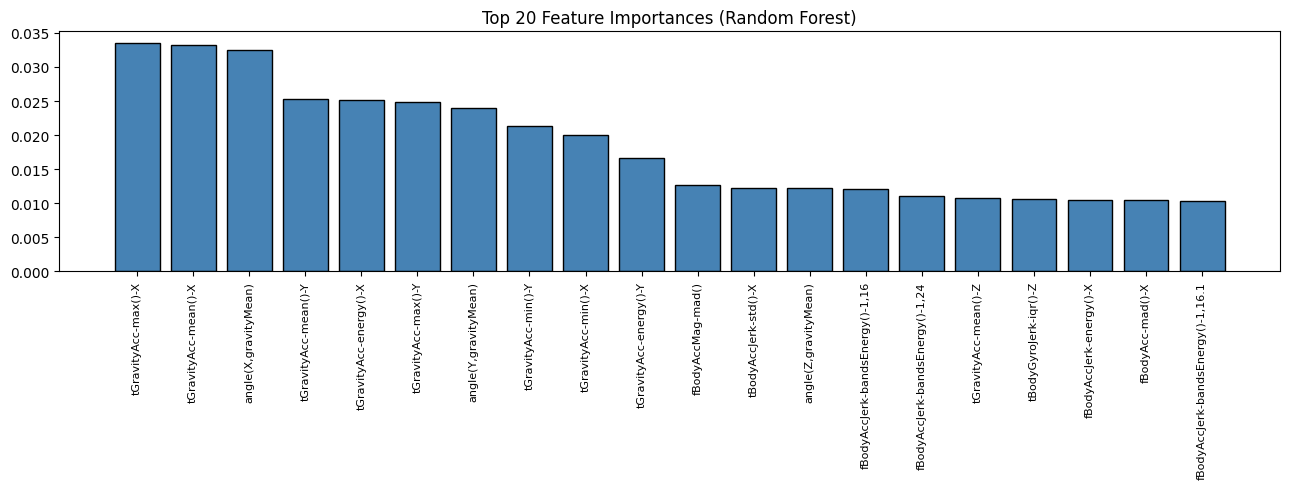

In [28]:
feature_names = df.drop(['Activity', 'Activity_enc', 'subject'], axis=1).columns.tolist()
importances   = rf.feature_importances_
top_n         = 20
top_idx       = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(13, 5))
plt.bar(range(top_n), importances[top_idx], color='steelblue', edgecolor='black')
plt.xticks(range(top_n), [feature_names[i] for i in top_idx], rotation=90, fontsize=8)
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

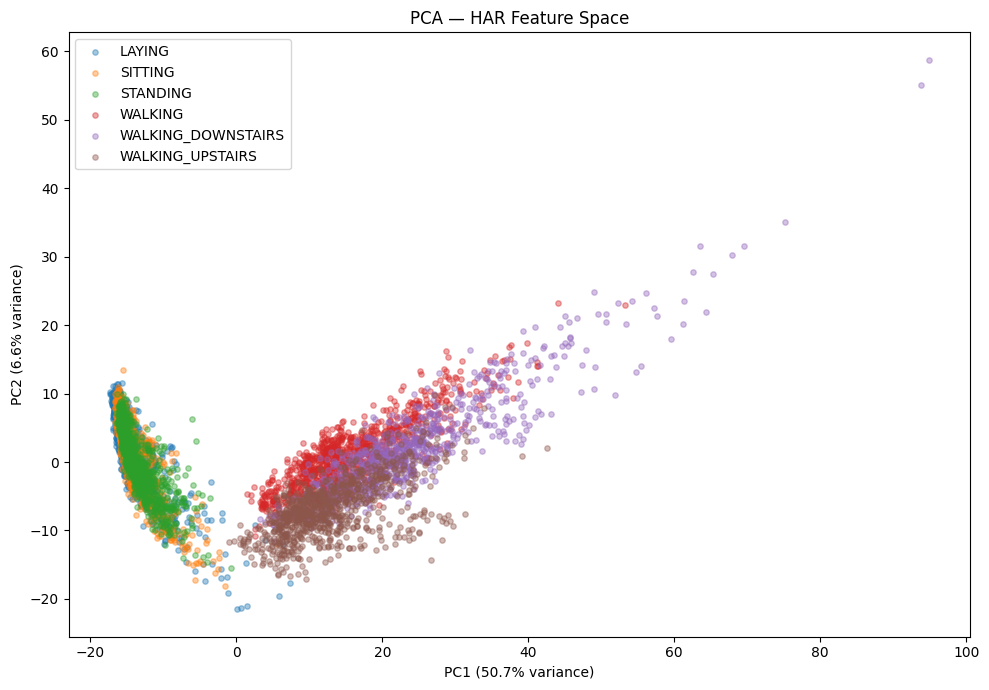

In [30]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', len(le.classes_))
for i, activity in enumerate(le.classes_):
    mask = y_train == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=activity,
                color=palette[i], alpha=0.4, s=15)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA — HAR Feature Space')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
joblib.dump(rf,            'har_model.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(le,            'label_encoder.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
print("Saved: har_model.pkl | scaler.pkl | label_encoder.pkl | feature_names.pkl")

Saved: har_model.pkl | scaler.pkl | label_encoder.pkl | feature_names.pkl


In [32]:
def predict_activity(sensor_features):
    """Predict activity from 561 sensor features."""
    features        = np.array(sensor_features).reshape(1, -1)
    features_scaled = scaler.transform(features)
    pred_idx        = rf.predict(features_scaled)[0]
    return le.inverse_transform([pred_idx])[0]

# Smoke test
print("Prediction:", predict_activity(X_test[0]))
print("Actual:    ", le.inverse_transform([y_test[0]])[0])

Prediction: WALKING_UPSTAIRS
Actual:     WALKING_UPSTAIRS
